# Waste Image Classifier 🗑️
### MobileNetV2 + PyTorch + Webcam Testing

This notebook trains a model to classify waste into 10 categories:
**battery, biological, cardboard, clothes, glass, metal, paper, plastic, shoes, trash**

At the end we test it live using the webcam!

## 1. Import Libraries

In [19]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import numpy as np
print("All libraries imported!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

All libraries imported!
PyTorch version: 2.10.0+cpu
CUDA available: False


In [ ]:

DATA_DIR = r'C:\Users\USERR\Desktop\depi project\standardized_2569'

MODEL_SAVE_PATH = 'waste_model.pth'

BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 0.001

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 3. Load the Dataset

We use `ImageFolder` — it reads class names from the folder names automatically.

Then we split 80% for training and 20% for validation.

In [3]:
# simple transforms — resize and convert to tensor, then normalize
# no fancy augmentation to keep things simple
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# load the full dataset
full_dataset = datasets.ImageFolder(root=DATA_DIR, transform=transform)

# get the class names from folder names
class_names = full_dataset.classes
num_classes = len(class_names)

print(f"Found {len(full_dataset)} images")
print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")

Found 12259 images
Number of classes: 10
Classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [4]:
# split into 80% train, 20% val
train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train samples: {train_size}")
print(f"Val samples:   {val_size}")

Train samples: 9807
Val samples:   2452


### Quick look at some training images

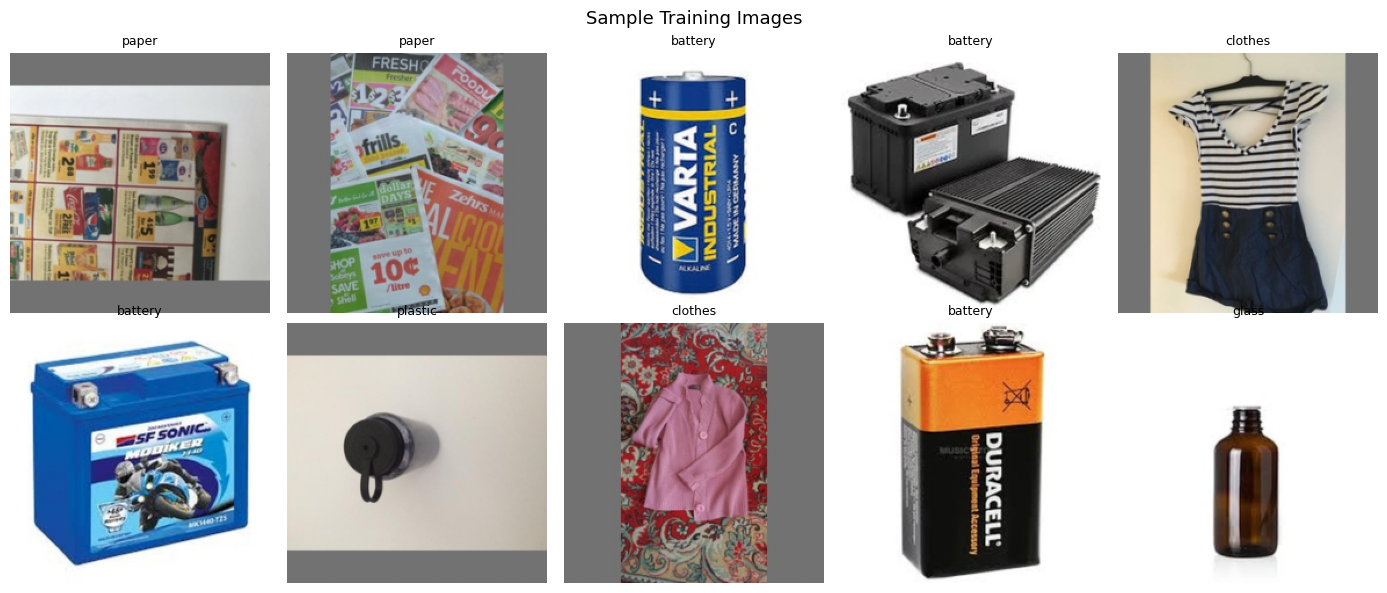

In [5]:
# show a few sample images from the training set
images, labels = next(iter(train_loader))

# undo the normalization so images look normal
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flatten()):
    img = images[i] * std + mean          # undo normalize
    img = img.permute(1, 2, 0).numpy()    # CHW -> HWC for matplotlib
    img = img.clip(0, 1)
    ax.imshow(img)
    ax.set_title(class_names[labels[i]], fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Training Images', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Build the Model

We use MobileNetV2 pretrained on ImageNet and just swap the last layer to output 10 classes.

In [6]:
# load pretrained MobileNetV2
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# replace the last layer — original outputs 1000 classes, we need num_classes
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

# move model to GPU or CPU
model = model.to(device)

print("Model ready!")
print(f"Output classes: {num_classes}")

Model ready!
Output classes: 10


## 5. Training Setup

In [7]:
# loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer — works well out of the box
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("Loss: CrossEntropyLoss")
print(f"Optimizer: Adam (lr={LEARNING_RATE})")

Loss: CrossEntropyLoss
Optimizer: Adam (lr=0.001)


## 6. Training Loop

We train for `NUM_EPOCHS` and print the loss + accuracy each epoch.

In [8]:
train_losses = []
train_accs   = []

print("Starting training...\n")

for epoch in range(NUM_EPOCHS):
    model.train()      # put model in training mode

    total_loss = 0
    correct    = 0
    total      = 0

    for images, labels in train_loader:
        # move data to device
        images = images.to(device)
        labels = labels.to(device)

        # forward pass
        outputs = model(images)
        loss    = criterion(outputs, labels)

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # track stats
        total_loss += loss.item()
        predicted   = outputs.argmax(dim=1)
        correct    += (predicted == labels).sum().item()
        total      += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total

    train_losses.append(avg_loss)
    train_accs.append(accuracy)

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  "
          f"Loss: {avg_loss:.4f}  "
          f"Train Accuracy: {accuracy:.2f}%")

print("\nTraining done!")

Starting training...

Epoch [1/10]  Loss: 0.7574  Train Accuracy: 75.63%
Epoch [2/10]  Loss: 0.4968  Train Accuracy: 83.51%
Epoch [3/10]  Loss: 0.4076  Train Accuracy: 86.68%
Epoch [4/10]  Loss: 0.3582  Train Accuracy: 88.36%
Epoch [5/10]  Loss: 0.3123  Train Accuracy: 89.89%
Epoch [6/10]  Loss: 0.2733  Train Accuracy: 91.16%
Epoch [7/10]  Loss: 0.2323  Train Accuracy: 92.60%
Epoch [8/10]  Loss: 0.2377  Train Accuracy: 92.24%
Epoch [9/10]  Loss: 0.1950  Train Accuracy: 93.47%
Epoch [10/10]  Loss: 0.2099  Train Accuracy: 93.17%

Training done!


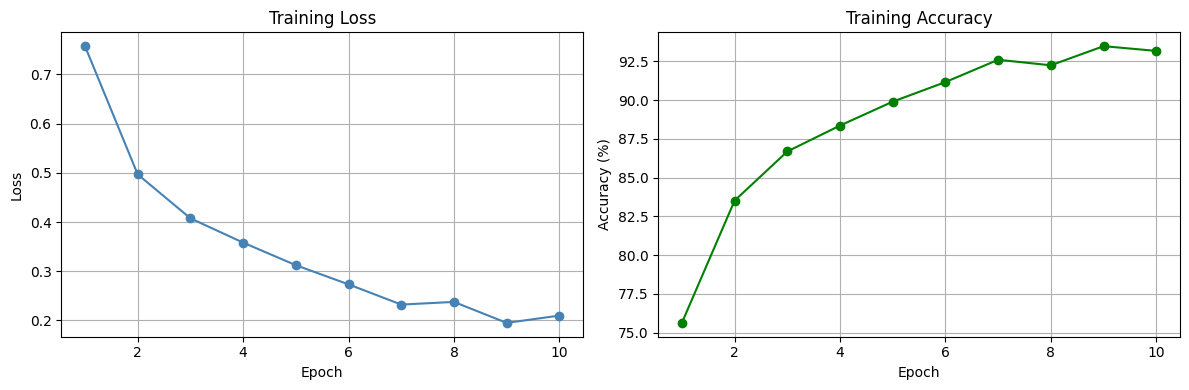

In [9]:
# plot the training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, NUM_EPOCHS+1), train_losses, marker='o', color='steelblue')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(range(1, NUM_EPOCHS+1), train_accs, marker='o', color='green')
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True)

plt.tight_layout()
plt.show()

## 7. Evaluate on Validation Set

In [10]:
model.eval()    # switch to eval mode (disables dropout etc.)

correct = 0
total   = 0

with torch.no_grad():    # no need to calculate gradients during evaluation
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs   = model(images)
        predicted = outputs.argmax(dim=1)

        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

val_accuracy = 100 * correct / total
print(f"Validation Accuracy: {val_accuracy:.2f}%")

Validation Accuracy: 87.89%


## 8. Save the Model

In [11]:
# save model weights + class names so we can load it later
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'num_classes': num_classes
}, MODEL_SAVE_PATH)

print(f"Model saved to: {MODEL_SAVE_PATH}")

Model saved to: waste_model.pth


## 9. Load the Saved Model

If you already have a trained model, you can skip the training section and just run this cell.

In [12]:
# load checkpoint
checkpoint  = torch.load(MODEL_SAVE_PATH, map_location=device)
class_names = checkpoint['class_names']
num_classes = checkpoint['num_classes']

# rebuild the same model architecture
model = models.mobilenet_v2(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print("Model loaded successfully!")
print(f"Classes: {class_names}")

Model loaded successfully!
Classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


## 10. Test on a Single Image

Run prediction on any image file — useful for quick testing before the webcam.

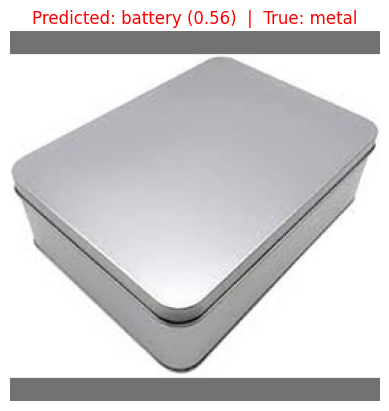

Input:  metal_575.jpg
Output: battery (0.56 confidence)
Correct: False


In [16]:
# the same transform we use at inference time (no augmentation)
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def predict_image(image_path):
    """Given an image path, returns the predicted class and confidence."""
    img    = Image.open(image_path).convert('RGB')
    tensor = inference_transform(img).unsqueeze(0).to(device)  # add batch dim

    with torch.no_grad():
        output     = model(tensor)
        probs      = torch.softmax(output, dim=1)[0]
        confidence, idx = probs.max(dim=0)

    predicted_class = class_names[idx.item()]
    confidence      = confidence.item()
    return predicted_class, confidence


# --- test it on a sample image ---
# pick the first image from the validation set as a demo
sample_path, sample_label_idx = full_dataset.samples[val_dataset.indices[0]]
true_label = class_names[sample_label_idx]

pred_class, confidence = predict_image(sample_path)

# show the image
img = Image.open(sample_path).convert('RGB')
plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {pred_class} ({confidence:.2f})  |  True: {true_label}",
          color='green' if pred_class == true_label else 'red')
plt.show()

print(f"Input:  {os.path.basename(sample_path)}")
print(f"Output: {pred_class} ({confidence:.2f} confidence)")
print(f"Correct: {pred_class == true_label}")

## 11. Webcam Testing 📷

Opens your webcam and classifies whatever it sees in real time.

- The predicted class and confidence are shown on screen
- Press **Q** to quit

> ⚠️ **Note:** This requires a physical webcam connected to the machine. It will NOT work on Colab — run this locally.

In [22]:

# transform for each webcam frame — same as inference
webcam_transform = transforms.Compose([
    transforms.ToPILImage(),              # convert numpy array to PIL
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def predict_frame(frame):
    """Takes a BGR frame from OpenCV, returns predicted class and confidence."""
    # OpenCV reads BGR, we convert to RGB for the model
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    tensor = webcam_transform(rgb_frame).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)[0]
        confidence, idx = probs.max(dim=0)

    return class_names[idx.item()], confidence.item()


# 🔥 NEW: approximate bounding box using contours
def get_object_bbox(frame):
    """Detect the largest object in the frame and return bounding box."""
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # edge detection
    edges = cv2.Canny(blur, 50, 150)

    # find contours
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)

        if cv2.contourArea(largest_contour) > 500:  # ignore noise
            x, y, w, h = cv2.boundingRect(largest_contour)
            return x, y, w, h

    return None


# --- open the webcam ---
cap = cv2.VideoCapture(0)   # 0 = default webcam

if not cap.isOpened():
    print("Could not open webcam!")
else:
    print("Webcam opened. Press Q to quit.")
    model.eval()

    while True:
        ret, frame = cap.read()

        if not ret:
            print("Failed to read frame.")
            break

        # get prediction for this frame
        label, conf = predict_frame(frame)

        # 🔥 NEW: get bounding box
        bbox = get_object_bbox(frame)

        if bbox is not None:
            x, y, w, h = bbox

            # draw bounding box
            cv2.rectangle(
                frame,
                (x, y),
                (x + w, y + h),
                (255, 0, 0),  # blue box
                2
            )

            # put label near box
            cv2.putText(
                frame,
                f"{label} ({conf:.2f})",
                (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (255, 0, 0),
                2
            )

        # draw a dark rectangle behind the text (original)
        text = f"{label} ({conf:.2f})"
        (text_w, text_h), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 1, 2)
        cv2.rectangle(frame, (10, 10), (20 + text_w, 50), (0, 0, 0), -1)

        # draw predicted class on the frame (original)
        cv2.putText(
            frame,
            text,
            (15, 42),
            cv2.FONT_HERSHEY_SIMPLEX,
            fontScale=1,
            color=(0, 255, 0),
            thickness=2
        )

        # show the frame
        cv2.imshow('Waste Classifier - Press Q to quit', frame)

        # press Q to exit
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # clean up
    cap.release()
    cv2.destroyAllWindows()
    print("Webcam closed.")

Webcam opened. Press Q to quit.
Webcam closed.
